In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o",
)

small_llm = ChatOpenAI(
    model="gpt-4o-mini",
)

In [3]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

간단한 웹 검색 도구 활용 

In [4]:
# %pip install -U ddgs

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [6]:
# %pip install -qU langchain-google-community\[gmail\]

In [7]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
# 참고: 라이브러리 파라미터명이 client_sercret_file (오타)로 되어 있음
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()


/var/folders/rb/wylmzgk90lb3vbd81tm_qck00000gn/T/ipykernel_48548/3036984763.py:11: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/rb/wylmzgk90lb3vbd81tm_qck00000gn/T/ipykernel_48548/3036984763.py:16: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [8]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x116fca3c0>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x116fca3c0>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x116fca3c0>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x116fca3c0>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x116fca3c0>)]

In [9]:
#%pip install langchain-community arxiv

In [10]:
# 최신 LangChain에서는 load_tools가 langchain_community로 이동함
from langchain_community.agent_toolkits.load_tools import load_tools

loaded_tool_list = load_tools(
    ["arxiv"],
)


In [11]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(
    model='text-embedding-3-large',
)
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to December 2024',
)

In [12]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list + loaded_tool_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [13]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str 
    
graph_builder = StateGraph(AgentState)

In [ ]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState) -> AgentState:
    """
    주어진 `state`에서 메시지를 가져와
    LLM과 도구를 사용하여 응답 메시지를 생성합니다.

    Args:
        state (AgentState): 메시지 기록과 요약을 포함하는 state.

    Returns:
        MessagesState: 응답 메시지를 포함하는 새로운 state.
    """
    # 메시지와 요약을 state에서 가져옵니다.
    messages = state['messages']
    summary = state['summary']

    """
    messages = 요약할 “원문”(최근 + 삭제 직전 메시지들)
    summary = 이미 압축된 “과거 대화”
    """
    
    # 요약이 비어있지 않으면, 요약을 메시지 앞에 추가합니다.
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    
    # LLM과 도구를 사용하여 메시지에 대한 응답을 생성합니다.
    response = llm_with_tools.invoke(messages)
    
    # 응답 메시지를 포함하는 새로운 state를 반환합니다.
    return {'messages': [response]}

In [15]:
def summarize_messages(state: AgentState) -> AgentState:
    """
    주어진 state의 메시지를 요약합니다.

    Args:
        state (AgentState): 메시지와 요약을 포함하는 state.

    Returns:
        AgentState: 요약된 메시지를 포함하는 딕셔너리.
    """
    # state에서 메시지와 요약을 가져옵니다.
    messages = state['messages']
    summary = state['summary']
    
    # 요약 프롬프트를 생성합니다.
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    
    # 기존 요약이 있으면, 요약을 포함한 프롬프트를 생성합니다.
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
chat_history:{messages}
summary:{summary}'''
    
    # LLM을 사용하여 요약을 생성합니다.
    summary = small_llm.invoke(summary_prompt)
    
    # 요약된 메시지를 반환합니다.
    return {'summary': summary.content}

In [16]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState) -> AgentState:
    """
    주어진 state에서 오래된 메시지를 삭제합니다.

    Args:
        state (AgentState): 메시지를 포함하는 state.

    Returns:
        AgentState: 삭제된 메시지를 포함하는 새로운 state.
    """
    # state에서 메시지를 가져옵니다.
    messages = state['messages']
    # 마지막 세 개의 메시지를 제외한 나머지 메시지를 삭제합니다.
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    # 삭제된 메시지를 포함하는 새로운 state를 반환합니다.
    return {'messages': delete_messages}

In [17]:
from typing import Literal

def should_continue(state: AgentState) -> Literal['tools', 'summarize_messages']:
    """
    주어진 state에 따라 다음 단계로 진행할지를 결정합니다.

    Args:
        state (AgentState): 메시지와 도구 호출 정보를 포함하는 state.

    Returns:
        Literal['tools', 'summarize_messages']: 다음 단계로 'tools' 또는 'summarize_messages'를 반환합니다.
    """
    # state에서 메시지를 가져옵니다.
    messages = state['messages']
    # 마지막 AI 메시지를 확인합니다.
    last_ai_message = messages[-1]
    
    # 마지막 AI 메시지가 도구 호출을 포함하고 있는지 확인합니다.
    if last_ai_message.tool_calls:
        # 도구 호출이 있으면 'tools'를 반환합니다.
        return 'tools'
    
    # 도구 호출이 없으면 'summarize_messages'를 반환합니다.
    return 'summarize_messages'

In [18]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

In [19]:
from langgraph.graph import START, END


graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [20]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph= graph_builder.compile(
    checkpointer=checkpointer
)

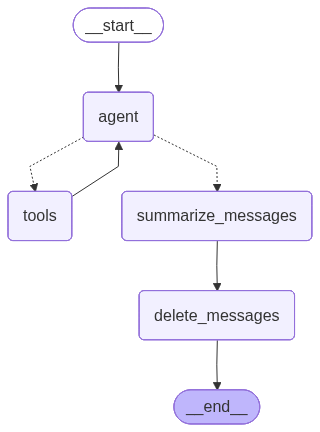

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

query = 'starirene9@gmail.com으로 Attention Is All You Need 논문을 요약해서 이메일 초안을 작성해주세요'
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

starirene9@gmail.com으로 Attention Is All You Need 논문을 요약해서 이메일 초안을 작성해주세요
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_7XQBxH3fbQDgJxt58BT6txXl)
 Call ID: call_7XQBxH3fbQDgJxt58BT6txXl
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention l

In [23]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 226, 'prompt_tokens': 1504, 'total_tokens': 1730, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_1590f93f9d', 'id': 'chatcmpl-D5WQoyjBVYs0wl6a08FOqUPueb3eC', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019c28a8-cd4d-7140-8a4f-124ab60bfcee-0', tool_calls=[{'name': 'create_gmail_draft', 'args': {'message': '안녕하세요,\n\n"Attention Is All You Need" 논문은 2017년에 발표되어 Transformer 아키텍처를 소개했습니다. 이 논문은 자연어 처리 분야에서의 중요한 이정표로, 기계 번역과 다양한 응용 프로그램에서 큰 혁신을 가져왔습니다.\n\n주요 내용은 다음과 같습니다:\n- 기존의 RNN 및 CNN 구조 대신 주의를 기울이는 메커니즘인 self-attention을 도입하여, 문맥 정보를 더 잘 포착합니다.\n- 이 아키텍처는 병렬 처리에 유리하여 더 빠른 학습 속도를 제공

In [24]:
graph.get_state(config).values['summary']

'The chat involves a user requesting a summary of the "Attention Is All You Need" paper to be drafted into an email. The AI responds by summarizing the key aspects of the paper, highlighting its introduction of the Transformer architecture and its significance in natural language processing (NLP). It mentions the use of self-attention mechanisms, benefits in parallel processing, and the resulting high performance in various NLP tasks. The AI then creates a draft email to the specified address, which includes this summary and invites feedback on the paper\'s impact on NLP. The draft is confirmed as completed, allowing the user to review and make any necessary edits.'

In [25]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

update_query = '논문의 출처 URL을 포함시켜주세요'
for chunk in graph.stream({'messages': [HumanMessage(update_query)]}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

논문의 출처 URL을 포함시켜주세요
================================== Ai Message ==================================
Tool Calls:
  create_gmail_draft (call_ULSncAwkZb5lmYJu0b1O4iT6)
 Call ID: call_ULSncAwkZb5lmYJu0b1O4iT6
  Args:
    message: 안녕하세요,

"Attention Is All You Need" 논문은 2017년에 발표되어 Transformer 아키텍처를 소개했습니다. 이 논문은 자연어 처리 분야에서의 중요한 이정표로, 기계 번역과 다양한 응용 프로그램에서 큰 혁신을 가져왔습니다.

주요 내용은 다음과 같습니다:
- 기존의 RNN 및 CNN 구조 대신 주의를 기울이는 메커니즘인 self-attention을 도입하여, 문맥 정보를 더 잘 포착합니다.
- 이 아키텍처는 병렬 처리에 유리하여 더 빠른 학습 속도를 제공합니다.
- 결과적으로, Transformer는 여러 NLP 작업에서 최고의 성능을 기록했습니다.

이 논문이 어떻게 자연어 처리의 패러다임을 바꾸었는지에 대한 귀하의 의견을 듣고 싶습니다!

논문 원문: https://arxiv.org/abs/1706.03762
    to: ['starirene9@gmail.com']
    subject: "Attention Is All You Need" 논문 요약
================================= Tool Message =================================
Name: create_gmail_draft

Draft created. Draft Id: r-9210432182082423613
================================== A

In [26]:
graph.get_state(config).values['summary']


'The chat centers around a user asking the AI to create a draft email summarizing the paper "Attention Is All You Need." The AI provides a concise summary of the paper, emphasizing the introduction of the Transformer architecture, the self-attention mechanism, its advantages in parallel processing, and its substantial impact on natural language processing (NLP). The AI subsequently drafts an email that includes the summary and solicits feedback on the paper’s influence. After an initial draft, the user requests the inclusion of the paper\'s URL, prompting the AI to update the draft accordingly. The final draft is completed and presented for the user\'s review and potential edits.'